# Logistic Regression

In [1]:
# importiamo i pacchetti necessari
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from  sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit

%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../..')

import src.class_funcs as fs

from IPython.display import Image, display

In [2]:
# scelta del seed random per la riproducibilità dei risultati
seed = 0

## Studio binario

Tramite questo studio di classificazione vogliamo essere in grado di effettuare previsioni sull'inquinamento dell'aria.\
Per sfruttare al massimo le conoscenze sviluppate in classe, scriviamo inizialmente il problema come un preblema di carattere binario. In particolare, etichettiamo come 1 = 'ok' tutti i punti con EAQI 'good' o 'fair' (AQI < 40), mentre chiamiamo 0 = 'not ok' i restanti punti con EAQI 'moderate', 'poor' o 'very poor'. Data una certa ora, cerchiamo quindi di prevedere se la qualità dell'aria sarà 'ok' o 'not ok' sulla base delle rilevazioni nelle ore a questa precedenti.

Costruiamo quindi il dataframe inserendo le ore precedenti a quella di target come specificato sopra.

Seppure la colonna 'winds_spd' sia molto correlata con gli inquinanti, contenendo diversi NaN, scegliamo per il momento di escluderla. L'influenza di questa feature sulle previsioni è approfondita nel notebook di appendice

In [3]:
binary_class_df = pd.read_csv('../../data/processed/dataset_binary_class_processed.csv')

# togliamo la colonna 'winds_spd'
binary_class_df.drop('winds_spd', axis=1, inplace=True)

# droppiamo poi anche diverse righe contenenti NaN sulle rilevazioni degli inquinanti (probabilmente dovute a malfunzionamenti dei sensori)
# in questo modo cancelliamo anche le righe legate alle rilevazioni di Riva del Garda visto che questa stazione è staccata dalla linea elettrica
binary_class_df.dropna(inplace=True)

binary_class_df.head()

,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano,elevation,day,cos_week_day,...,PM10_3,NO2_3,AQI_3,power_area_50_3,temperature,precipitation,PM10_diff,NO2_diff,AQI_diff,target
0,1,0,0,0,0,0,0,410,1,-0.900969,...,19.0,19.0,24.0,17.861264,10.950,0.0,1.0,1.0,4.0,1
1,1,0,0,0,0,0,0,410,1,-0.900969,...,20.0,17.0,22.0,14.669913,11.000,0.0,-2.0,-2.0,0.0,1
2,1,0,0,0,0,0,0,410,1,-0.900969,...,21.0,18.0,26.0,16.969367,10.925,0.0,5.0,0.0,6.0,1
3,1,0,0,0,0,0,0,410,1,-0.900969,...,19.0,16.0,26.0,15.329278,10.950,0.0,-5.0,-1.0,-10.0,1
4,1,0,0,0,0,0,0,410,1,-0.900969,...,24.0,16.0,32.0,17.519438,11.550,0.0,3.0,0.0,2.0,1


### Discussione time-series dataset
Il nostro dataset di riferimento non è fatto di punti indipendenti, ma di ordinati temporalmente. Per questo motivo utilizzare i metodi standard sviluppati in classe creerebbe diversi data leakage più o meno importanti.
Le modifiche più importanti che individuiamo che seguono da questa consapevolezza sono:
- Una suddivisione cronologica con gap tra train, valid e test: per fare in modo che il modello non colga informazioni dal futuro, scegliamo di ordinare nel tempo le tre sezioni in cui dividiamo il dataset.
- Al posto di usare la cross-validation standard, utilizziamo la cross-validation implementata TimeSeriesSplit ("cross-validation on a rolling basis")

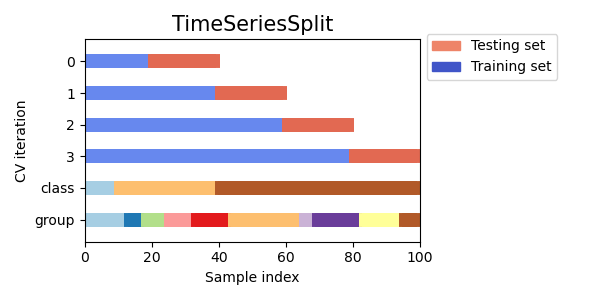

In [4]:
# per rendere più chiaro quello che stiamo facendo, riportiamo l'immagine trovata sul sito di sickit-learn
display(Image(filename='../../images/sphx_glr_plot_cv_indices_013.png'))

### Pipeline
Dato che la procedura standardizzazione-fit/predict verrà usata molto, vogliamo provare ad automatizzare questo processo usando una pipeline. Nella pipeline vogliamo fare in modo che vengano standardizzate solo alcune colonne e non altre.

La pipeline è particolarmente appropriata nel nostro caso perché, usando la cross validation autoimplementata in sickit-learn, la pipeline riscala il train ad ogni iterazione del k-fold, per cui si evita leakage interno al train

In [5]:
# individuiamo le colonne numeriche e quelle non numeriche
non_num_features = [col for col in binary_class_df.columns if col.startswith('station_')]
num_features = binary_class_df.columns.difference(non_num_features + ['target'])

# per il preprocessing usiamo ColumnTransformer, che permette di trasformare diverse colonne in modo diverso
preprocessor_binary = ColumnTransformer(
    [('num', StandardScaler(), num_features),
     ('one-hot', 'passthrough', non_num_features)])

tscv = TimeSeriesSplit(n_splits=5)

classifier_binary = LogisticRegressionCV(
    Cs=10,                                                          # numero di C = 1/lambda testati
    cv=tscv,                                                        # cv = n => n-fold cross validation
    solver='saga',                                                  # scegliamo saga, che è l'unico che supporta elasticnet
    l1_ratios=[0,0.25,0.5,0.75,1.0],                                # ratei tra l1 e l2 da testare
    scoring=metrics.make_scorer(metrics.matthews_corrcoef),         # usiamo mcc come score perché le classi sono sbilanciate e non abbiamo preferenze tra fpr e fnr
    max_iter=5000,                                                  # numero massimo di iterazioni per l'ottimizzazione
    n_jobs = -1,                                                    # usiamo la massima potenza disponibile nella CPU
    class_weight='balanced',                                        # bilancia in automatico le classi in base alla frequenza di input
    random_state=seed                                               # per la riproducibilità dei risultati
)

# costruiamo la nostra pipeline vera e propria
model_binary = Pipeline(steps=[('preprocessor', preprocessor_binary),('classifier', classifier_binary)])

### Train, Valid, Test split + fit
Dividiamo quindi il dataset in train (70%), valid (15%) e test (15%). Utilizziamo la cross-validation k-fold già implementata in LogisticRegressionCV. Introduciamo valid come insieme su cui scegliere il threshold più adatto per la logistic regression. Dopo aver scelto quest'ultima, rialleniamo il modello su train + valid e lo testiamo su test.

In [6]:
# splittiamo il dataset e facciamo il fit al modello
feature_cols = list(num_features) + list(non_num_features)

# creiamo train, valid e test
bi_X_train, bi_X_valid, bi_X_test, bi_y_train, bi_y_valid, bi_y_test = fs.get_train_valid_test(binary_class_df, 0.7, 0.15, feature_cols)

In [7]:
# alleniamo il modello sul nostro insieme di training
model_binary.fit(bi_X_train,bi_y_train)

/Users/carlo/opt/anaconda3/envs/DS26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('one-hot', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

### Studio importanza features
Quali sono le features più importanti?

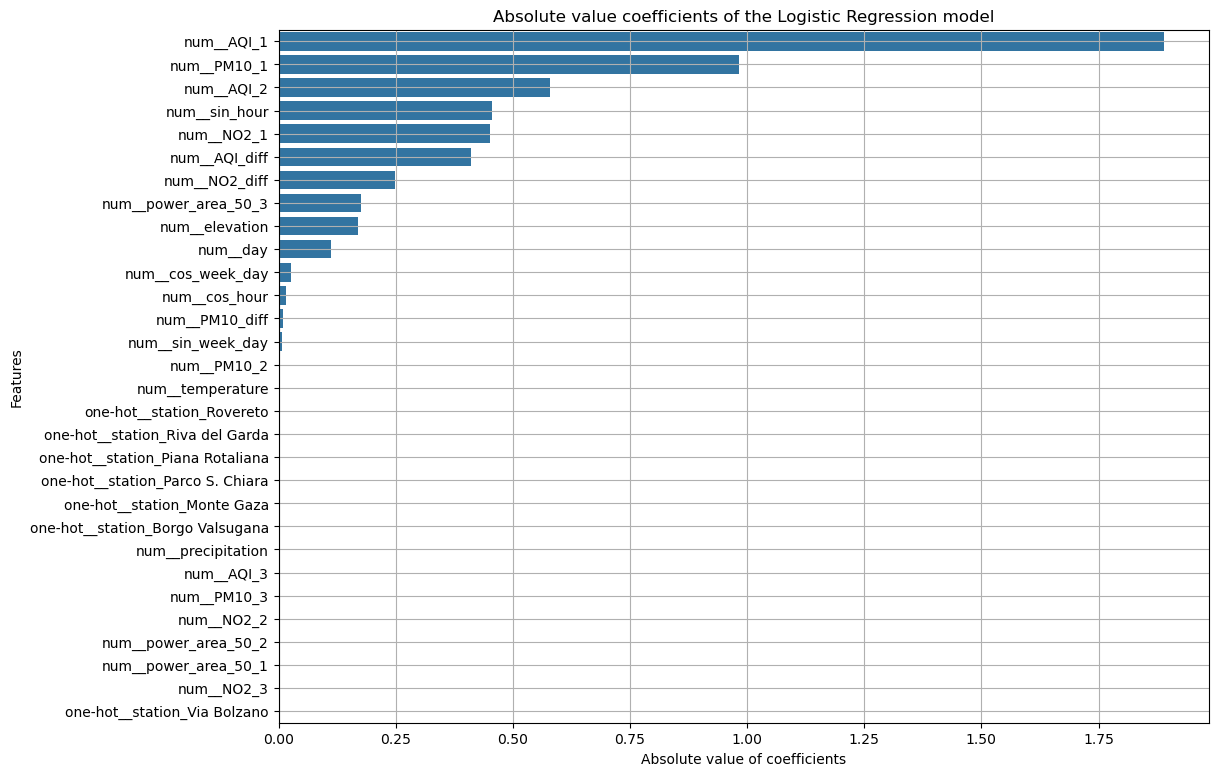

In [8]:
# tiro fuori i nomi delle feature come li ha presi il trasformatore (in questo modo non rischio di scambiare le features)
feature_names = model_binary.named_steps['preprocessor'].get_feature_names_out()

# rappresento il valore assoluto dei coefficienti
fs.display_abs_coefs(model_binary.named_steps['classifier'],feature_names)

Come ci potevamo aspettare, le feature più importanti sono quelle con le indicazioni sugli inquinanti nelle ore precedenti quella in studio. In mezzo a questi si inserisce il ciclo giornaliero, che, come visto nell'EDA, ha delle fluttuazioni caratteristiche e rilevanti.

Feature rilevante è anche il dato sui consumi elettrici tre ore prima dell'ora in studio. Particolarmente interessante è proprio che il dato rilevante è proprio quello di tre ore prima. Probabilmente questo è dovuto al fatto che, come visto, la correlazione tra inquinanti e consumi aumentava leggermente aumentando il delay, raggiungendo un massimo e poi diminuendo. Magari le altre features sull'energia sono particolarmente meno rilevanti perché portano più o meno la stessa informazione della feature relativa a tre ore prima.

Interessante è anche il fatto che le stazioni non sembrano particolarmente rilevanti nello studio. Magari è anche dovuto al fatto che, andando in ordine cronologico, non vengono fuori le grandi differenze tra le stazioni che si vedono verso Natale.

Stranamente i dati meteo sono irrilevanti. Ci saremmo aspettati una dipendenza maggiore, ma forse questo dato è dovuto all'intervallo di tempo molto limitato in studio.

### Studio matrici di confusione
Studiamo quindi le matrici di confusione per train e valid, capiamo come si comporti il nostro modello ed individuiamo un eventuale overfitting

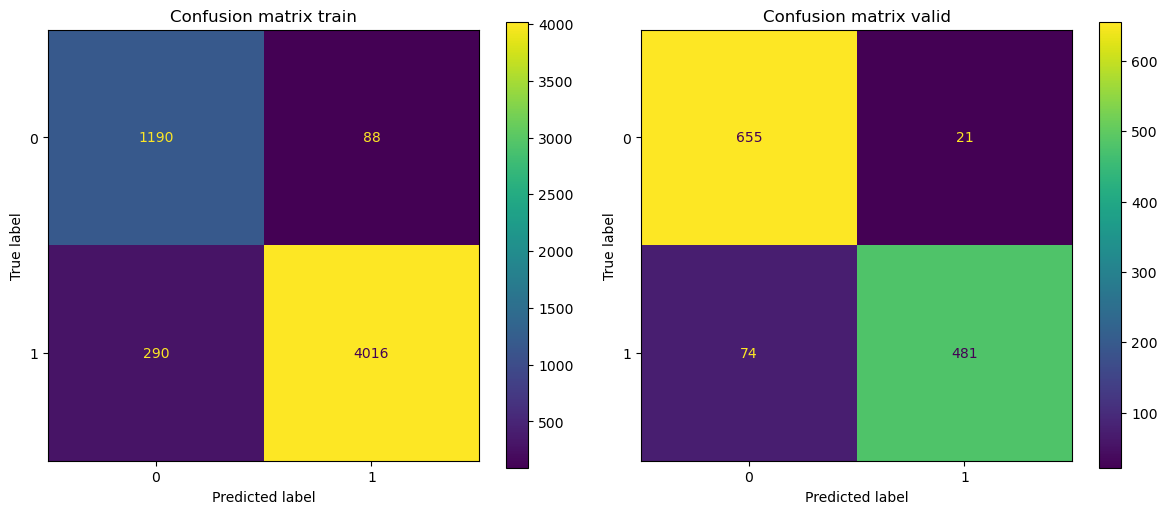

Accuratezza: 0.92283
Precisione: 0.95817
Recall: 0.86667
F1 score: 0.91012
MCC: 0.84606


In [9]:
fs.display_confusion_matrix(model_binary, 'Confusion matrix train', bi_X_train, bi_y_train, 'Confusion matrix valid', bi_X_valid, bi_y_valid)

fs.get_performance_param(model_binary, bi_X_valid, bi_y_valid)

Non sembra ci sia overfitting, ma i risultati sono comunque molto rumorosi.

Una cosa da tenere a mente e che è particolarmente evidente qui è il progressivo peggioramento della qualità dell'aria nell'andare verso Natale. Avendo a disposizione un intervallo di tempo così limitato, questo vuol dire che in realtà l'insieme di train sarà abbastanza diverso da quello di valid e test, con questi ultimi due che avrenno una frazione di 'not ok' molto maggiore rispetto al train.
Sempre guardando l'andamento temporale della qualità dell'aria, ci possiamo aspettare che la performance sul train sarà migliore di quella sul train, visto che quest'ultimo è composto per una gran parte da giorni successivi a Natale e quindi è più simile al train come distribuzione dei punti.

Detto ciò, anche guardando i parametri di performance, sembra che per una semplice logistic regression il modello funzioni piuttosto bene.Il dato peggiore è l'MCC, che comunque non è il massimo visto che è il parametro che vorremmo massimizzare. 

Proviamo a migliorare l'MCC scegliendo il miglior threshold su valid nella prossima sezione.

### Ottimizzazione del threshold
Avendo delle classi molto sbilanciate, siamo interessati ad ottimizzare il threshold utilizzando l'MCC come parametro da massimizzare.

Anche sapendo questo, può essere interessante ed educativo passare prima attraverso la curva ROC e Precision-Recall. Inoltre, vogliamo valutare anche metodi diversi per scegliere il miglior threshold.

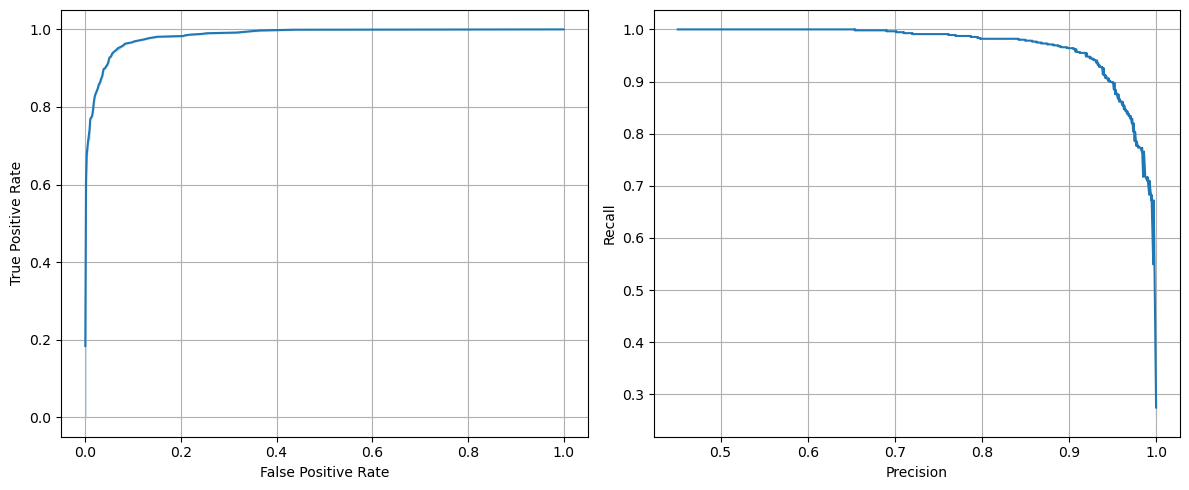

In [10]:
# disegnamo la curva ROC e Precision-Recall
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

y_proba_va = model_binary.predict_proba(bi_X_valid)[:, 1] # restituisce le predizioni in forma di probabilità, quindi permette di disegnare la ROC

# parametri per la curva ROC
fpr,tpr,thr = metrics.roc_curve(bi_y_valid,y_proba_va)

ax0 = axes[0]
sns.lineplot(x=fpr, y=tpr, ax=ax0)
ax0.set_xlabel('False Positive Rate')
ax0.set_ylabel('True Positive Rate')
ax0.grid()

# parametri per la curva Precision-Recall
prec,rec,thr = metrics.precision_recall_curve(bi_y_valid,y_proba_va)

ax1 = axes[1]
sns.lineplot(x=prec, y=rec, ax=ax1)
ax1.set_xlabel('Precision')
ax1.set_ylabel('Recall')
ax1.grid()

plt.tight_layout()

Come aspettato, vista la performance abbastanza buona del modello, la curva ROC è molto lontana dalla diagonale (molto poco casuale) e anche la curva Precision-Recall è molto spostata verso l'angolo in alto a destra.

Rappresentiamo anche curva Precision e Recall separate in funzione del threshold

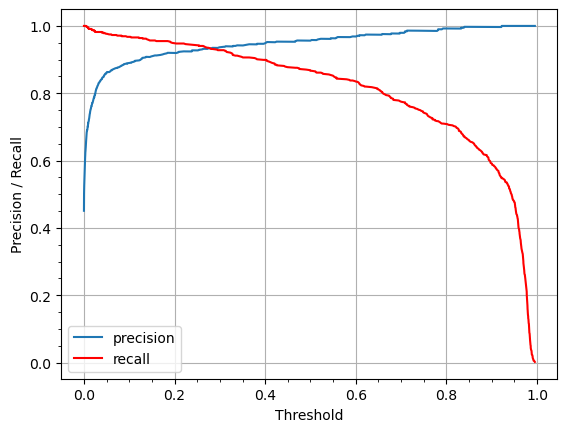

In [11]:
ax = sns.lineplot(x=thr, y=prec[:-1], label='precision')
sns.lineplot(x=thr,y=rec[:-1],label='recall',color='red', ax=ax)
ax.set_xlabel('Threshold')
ax.set_ylabel('Precision / Recall')
ax.minorticks_on()
ax.grid(visible= True)

Come aspettato, la precision = TP / PP aumenta all'aumentare del threshold, andando a 1 per il threshold che diventa 1:\
per thr -> 1, TP -> 0 e PP -> 0 => prec -> 1, per thr -> 0, TP -> AP e PP -> n => prec -> AP / n, è ≠ 0.5 se le classi sono sbilanciate

Al contrario, il recall = TP / AP diminuisce all'aumentare del threshold:\
per thr -> 1, TP -> 0 e AP = const => rec -> 0, per thr -> 0, TP -> AP => rec -> 1

Possiamo scegliere il threshold in diversi modi:
1. non volendo assegnare costi diversi ad una classe rispetto all'altra, una retta a pari performance (cioè a pari costo) nel grafico della ROC è una retta con coefficiente angolare P(N) / P(P) = #N / #P. In questa ottica, il threshold migliore è quindi il threshold che massimizza l'intercetta di questa retta (punto in cui la retta è tangente);

2. guardando online, un altro metro di scelta basato sulla ROC è la statistica J di Youden (si veda https://en.wikipedia.org/wiki/Youden%27s_J_statistic). In pratica il punto con migliore threshold è il punto che massimizza il valore J = sensitivity + specificity - 1 = TPR - FPR;

3. si può scegliere il threshold come punto di intersezione tra Precision e Recall. In questo modo non preferiamo una curva all'altra;

4. studiando il F1-score, si può scegliere il threshold che massimizza questo parametro, anche se questo è più adatto ai contesti in cui ci interessano particolarmente i positivi;

5. studiando il Matthews Correlation Coefficient (MCC), si può scegliere il threshold che massimizza questo parametro. In generale, questo studio è particolarmente adatto allo studio di classi sbilanciate, che è proprio il nostro caso.

Dopo aver comparato sull'insieme di validazione i diversi threshold ottenuti in questo modo, rialleniamo il modello e passiamo finalmente alla valutazione della predittività del modello sull'insieme di test.

In [15]:
y_proba_va = model_binary.predict_proba(bi_X_valid)[:, 1]

# 1. Intercetta
num_P = bi_y_valid.sum()
num_N = len(bi_y_valid) - num_P

fpr,tpr,thr_roc = metrics.roc_curve(bi_y_valid,y_proba_va)

mx = (num_N /num_P) * fpr
intercept = tpr[:-1] - mx[:-1]

best_idx = np.argmax(intercept)
best_thr_int = thr_roc[best_idx]
print(f'Threshold metodo intercetta: {best_thr_int:.5f}')

# 2. statistica J di Youden
J_score = tpr[:-1] - fpr[:-1]

best_idx = np.argmax(J_score)
best_thr_J = thr_roc[best_idx]
print(f'Threshold statistica J di Youden: {best_thr_J:.5f}')

# 3. intersezione Precision-Recall
prec,rec,thr_pre = metrics.precision_recall_curve(bi_y_valid,y_proba_va)

best_idx = np.argmin(np.abs(prec[:-1] - rec[:-1]))
best_thr_PR = thr_pre[best_idx]
print(f'Threshold intersezione Precision-Recall: {best_thr_PR:.5f}')

# 4. F1-score
f1_score = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1])
best_idx = np.argmax(f1_score)
best_thr_f1 = thr_pre[best_idx]
print(f'Threshold F1-score: {best_thr_f1:.5f}')

thr = np.linspace(0, 1, int(1e3))

# 5. MCC
max_MCC_score = -1
best_thr_MCC = None

for t in thr:
    y_pred = (y_proba_va >= t).astype(int)
    MCC_score = metrics.matthews_corrcoef(bi_y_valid, y_pred)

    if (MCC_score > max_MCC_score):
        max_MCC_score = MCC_score
        best_thr_MCC = t


print(f'Threshold MCC: {best_thr_MCC:.5f}')

Threshold metodo intercetta: 0.26279
Threshold statistica J di Youden: 0.18474
Threshold intersezione Precision-Recall: 0.27924
Threshold F1-score: 0.18474
Threshold MCC: 0.18318


È interessante notare come la scelta della migliore threshold si riduca sostanzialmente a due possibilità:
- una threshold "alta", per i metodi dell'intercetta e dell'intersezione tra curve Precision e Recall.
- una threshold "bassa", per i restanti tre metodi.

Il primo di questi due gruppi ha un approccio tendenzialmente più neutro di fronte allo sbilanciamento delle classi, che qui è particolarmente rilevante. In particolare, il risultato sull'intercetta potrebbe anche essere dovuto al fatto che, mentre train è molto sbilanciato sulla classe 1, valid sembra avere molto meno sbilanciamento, per cui la situazione è diversa.

In ogni caso, come preannunciato, scegliamo il coefficiente di correlazione di Matthews come metrica da massimizzare.

### Retrain su train + valid e studio di test

In [17]:
# uniamo train e valid
bi_X_train_valid = pd.concat([bi_X_train, bi_X_valid], ignore_index=True)
bi_y_train_valid = pd.concat([bi_y_train, bi_y_valid], ignore_index=True)

# alleniamo il modello
model_binary.fit(bi_X_train_valid,bi_y_train_valid)

/Users/carlo/opt/anaconda3/envs/DS26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('one-hot', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

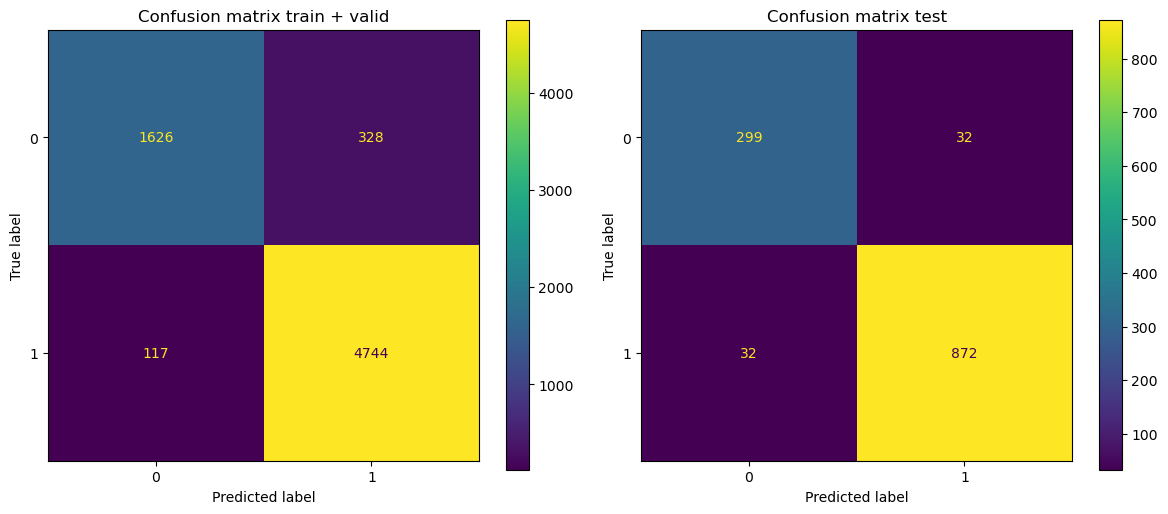

In [18]:
fs.display_confusion_matrix(model_binary, 'Confusion matrix train + valid', bi_X_train_valid, bi_y_train_valid, 'Confusion matrix test', bi_X_test, bi_y_test, best_thr_MCC)

In [19]:
fs.get_performance_param(model_binary, bi_X_test, bi_y_test, thr=best_thr_MCC)

Accuratezza: 0.94818
Precisione: 0.96460
Recall: 0.96460
F1 score: 0.96460
MCC: 0.86793


Il modello mostra risultati peggiori sul test di quanto avesse fatto sul valid. Questo non pensiamo sia dovuto a problemi di overfitting, quanto piuttosto ad una semplice varianza statistica dei risultati. Cambiando seed per lo studio questa stranezza si risolve.

In generale, con i parametri di performance scritti qui sopra, riteniamo il modello sufficientemente predittivo per una semplice logistic regression. Successivamente si proverà a riaffrontare il problema usando la Random Forest, per cui si predicono risultati molto migliori.

Avendo capito che per due classi la logistic regression ha risultati abbastanza buoni, proviamo a capire se il modello risulti predittivo anche nel caso in cui si provassero a predire tutte e 5 le classi dell'EAQI

## Classificazione a 5 classi

In [66]:
# cominciamo importando il dataframe precedentemente preparato
multiclass_df = pd.read_csv('../../data/processed/dataset_multiclass_processed.csv')

# come fatto per il problema binario togliamo la colonna 'winds_spd'
multiclass_df.drop('winds_spd', axis=1, inplace=True)

# droppiamo poi anche diverse righe contenenti NaN
multiclass_df.dropna(inplace=True) 

multiclass_df.head()

,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano,elevation,day,cos_week_day,...,PM10_3,NO2_3,AQI_3,power_area_50_3,temperature,precipitation,PM10_diff,NO2_diff,AQI_diff,target
0,1,0,0,0,0,0,0,410,1,-0.900969,...,19.0,19.0,24.0,17.861264,10.950,0.0,1.0,1.0,4.0,fair
1,1,0,0,0,0,0,0,410,1,-0.900969,...,20.0,17.0,22.0,14.669913,11.000,0.0,-2.0,-2.0,0.0,fair
2,1,0,0,0,0,0,0,410,1,-0.900969,...,21.0,18.0,26.0,16.969367,10.925,0.0,5.0,0.0,6.0,fair
3,1,0,0,0,0,0,0,410,1,-0.900969,...,19.0,16.0,26.0,15.329278,10.950,0.0,-5.0,-1.0,-10.0,fair
4,1,0,0,0,0,0,0,410,1,-0.900969,...,24.0,16.0,32.0,17.519438,11.550,0.0,3.0,0.0,2.0,fair


In [67]:
# contiamo al volo il numeo di punti per ciascuna classe
multiclass_df['target'].value_counts()

target
good         2908
fair         2857
poor         1336
moderate      795
very poor     154
Name: count, dtype: int64

Notiamo come le classi sono profondamente sbilanciate. In particolare la cardinalità di 'very poor' è molto minore rispetto a tutte le altre classi. Teniamo a mente questo per la fase di validazione del modello.

### Pipeline
Allenare il modello multiclasse con 'saga', l'elasticnet e gli stessi parametri di prima richiede molto tempo (quasi un'ora in un MacBook Air con M1). Questo è giustificato dal fatto che, tutto compreso, alleniamo e confrontiamo 250 modelli diversi (5-fold CV con 10 valori per lambda e 5 ratei per l'elasticnet). Inoltre il solver 'saga' sembra particolarmente lento a convergere, raggiungendo max_iter anche se imponiamo max_iter=5000. 

Vogliamo quindi cambiare qualcosa. Proviamo innanzitutto ad usare il solver 'lbfgs', che dovrebbe essere più rapido a convergere. Si noti però che in questo modo escludiamo la possibilità di usare elasticnet. Usiamo quindi separatamente 'l1' ed 'l2' e scegliamo il risultato migliore.

In [68]:
# individuiamo le colonne numeriche e quelle non numeriche
non_num_features = [col for col in multiclass_df.columns if col.startswith('station_')]
num_features = multiclass_df.columns.difference(non_num_features + ['target'])

# per il preprocessing usiamo ColumnTransformer, che permette di trasformare diverse colonne in modo diverso
preprocessor_multiclass = ColumnTransformer(
    [('num', StandardScaler(), num_features),
     ('one-hot', 'passthrough', non_num_features)])

tscv = TimeSeriesSplit(n_splits=5)

classifier_multiclass = LogisticRegressionCV(
    Cs=10,                                                          # numero di C = 1/lambda testati
    cv=tscv,                                                        # cv = n => n-fold cross validation
    solver='saga',                                                  # scegliamo saga, che è l'unico che supporta elasticnet
    l1_ratios=[0,0.25,0.5,0.75,1.0],                                # ratei tra l1 e l2 da testare
    scoring=metrics.make_scorer(metrics.matthews_corrcoef),         # usiamo mcc come score perché le classi sono sbilanciate e non abbiamo preferenze tra fpr e fnr
    max_iter=5000,                                                  # numero massimo di iterazioni per l'ottimizzazione
    n_jobs = -1,                                                    # usiamo la massima potenza disponibile nella CPU
    class_weight='balanced',                                        # bilancia in automatico le classi in base alla frequenza di input
    random_state=seed                                               # per la riproducibilità dei risultati
)

# costruiamo la nostra pipeline vera e propria
model_multiclass = Pipeline(steps=[('preprocessor', preprocessor_multiclass),('classifier', classifier_multiclass)])

### Train, Valid, Test split
Seguiamo la stessa suddivisione vista sopra: dividiamo in un 70%, 15%, 15%

In [69]:
# splittiamo il dataset e facciamo il fit al modello
feature_cols = list(num_features) + list(non_num_features)

# creiamo train, valid e test
mc_X_train, mc_X_valid, mc_X_test, mc_y_train, mc_y_valid, mc_y_test = fs.get_train_valid_test(multiclass_df, 0.7, 0.15, feature_cols)

In [ ]:
model_multiclass.fit(mc_X_train,mc_y_train)

/Users/carlo/opt/anaconda3/envs/DS26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/carlo/opt/anaconda3/envs/DS26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/carlo/opt/anaconda3/envs/DS26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/carlo/opt/anaconda3/envs/DS26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/carlo/opt/anaconda3/envs/DS26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.w

Vediamo quanto bene prevede il nostro modello

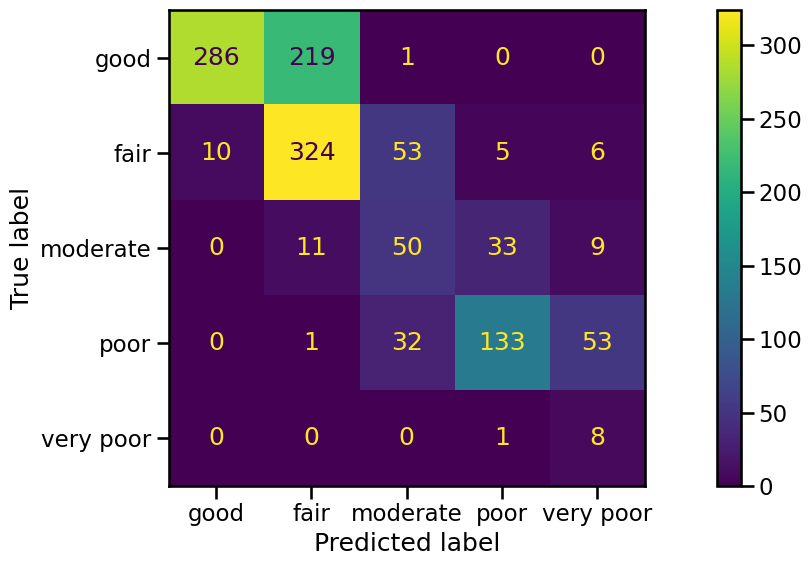

Accuratezza: 0.64858
Precisione: 0.75256
Recall: 0.64858
F1 score: 0.66825
MCC: 0.53222


In [ ]:
y_pred = model_multiclass.predict(mc_X_valid)

fig, ax = plt.subplots(figsize=(15,6))

class_order = ['good', 'fair', 'moderate', 'poor', 'very poor']

metrics.ConfusionMatrixDisplay.from_predictions(mc_y_valid,y_pred,display_labels=class_order, labels=class_order, ax=ax)

plt.tight_layout()

plt.show()

y_pred = model_multiclass.predict(mc_X_valid)
accuracy_score = metrics.accuracy_score(mc_y_valid, y_pred)
precision_score = metrics.precision_score(mc_y_valid, y_pred, average='weighted')
recall_score = metrics.recall_score(mc_y_valid, y_pred, average='weighted')
f1_score = metrics.f1_score(mc_y_valid, y_pred, average='weighted')
MCC_score = metrics.matthews_corrcoef(mc_y_valid, y_pred)

print(f'Accuratezza: {accuracy_score:.5f}')
print(f'Precisione: {precision_score:.5f}')
print(f'Recall: {recall_score:.5f}')
print(f'F1 score: {f1_score:.5f}')
print(f'MCC: {MCC_score:.5f}')

Sia dalla confusion matrix, che dai parametri di performance sembra che il nostro modello non sia molto predittivo. In particolare, la classe 'very poor' viene predetta male più volte di quanto non venga predetta bene. Questo può essere aspettato, visto che il dataframe ha pochi punti relativi a questa classe e quindi il modello non riesce a comprenderne bene le caratteristiche.

Proviamo a riallenare il modello, ma unendo la classe 'very poor' a 'poor'. In questo modo rendiamo anche le classi più bilanciate.

In [ ]:
mod_five_class_df = five_class_df.copy()

# sostituiamo i 'very poor' nella colonna
mod_five_class_df['target'] = mod_five_class_df['target'].replace('very poor', 'poor')

# ritrasformiamo il nostro dataframe


,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano,monday,tuesday,wednesday,...,NO2_2,AQI_2,power_area_50_2,PM10_3,NO2_3,AQI_3,power_area_50_3,temperature,precipitation,target


In [ ]:
y_pred = logreg.predict(scaled_test)
conf_mat  = confusion_matrix(test['target'], y_pred)
ConfusionMatrixDisplay(conf_mat, display_labels=logreg.classes_)
plt.show()

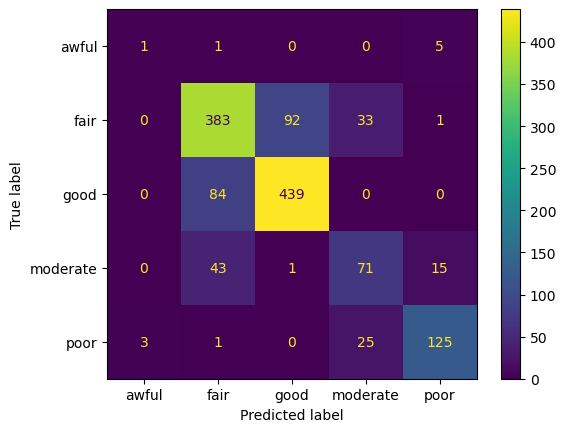

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    test['target'],
    y_pred,
    display_labels=logreg.classes_
)

plt.show()

# Per facilità di studio, rifacciamo il conto con solamente due classi

In [ ]:
map2d = {'good': 'ok', 'fair': 'ok', 'moderate': 'ok', 'poor': 'not ok', 'awful': 'not ok'}
classification_df['target'] = classification_df['target'].map(map2d)

classification_df.head()



,day,hour,elevation,PM10_1,NO2_1,AQI_1,tot_area_power_1,temperature_1,precipitation_5,PM10_2,...,martedì,mercoledì,sabato,venerdì,Borgo Valsugana,Monte Gaza,Parco S. Chiara,Rovereto,Via Bolzano,target
8,2,8,410,23.0,16.0,25.000000,927.923195,9.6,0.0,23.0,...,False,False,True,False,True,False,False,False,False,ok
9,2,9,410,24.0,21.0,26.666667,921.967223,9.9,0.0,23.0,...,False,False,True,False,True,False,False,False,False,ok
10,2,10,410,29.0,19.0,35.000000,916.103636,10.3,0.0,24.0,...,False,False,True,False,True,False,False,False,False,ok
11,2,11,410,29.0,23.0,35.000000,913.024411,11.0,0.0,29.0,...,False,False,True,False,True,False,False,False,False,ok
12,2,12,410,27.0,23.0,31.666667,909.916536,11.4,0.4,29.0,...,False,False,True,False,True,False,False,False,False,ok


In [ ]:
# creo train, valid e test
feature_cols = classification_df.columns.difference(['target'])
X_train, X_test, y_train, y_test= train_test_split(classification_df[feature_cols], classification_df['target'], test_size=0.2, random_state=12)

# riscalo mettendo la media a 0 e la deviazione std a 1
non_num_features = ['day', 'hour', 'lunedì', 'martedì', 'mercoledì', 'giovedì', 'venerdì', 'sabato', 'domenica', 'Borgo Valsugana', 'Monte Gaza', 'Parco S. Chiara', 
                    'Rovereto', 'Via Bolzano']
num_features = X_train.columns.difference(non_num_features)

scaler = StandardScaler()
scaled_num_X_train = scaler.fit_transform(X_train[num_features])
scaled_num_X_test = scaler.transform(X_test[num_features])

scaled_X_train = X_train.copy()
scaled_X_test = X_test.copy()

scaled_X_train[num_features] = scaled_num_X_train
scaled_X_test[num_features] = scaled_num_X_test

scaled_X_train.head()

,AQI_1,AQI_2,AQI_3,Borgo Valsugana,Monte Gaza,NO2_1,NO2_2,NO2_3,PM10_1,PM10_2,...,precipitation_6,precipitation_7,sabato,temperature_1,temperature_2,temperature_3,tot_area_power_1,tot_area_power_2,tot_area_power_3,venerdì
4481,-0.494027,-0.508842,-0.635002,False,False,0.531191,0.502242,-0.068977,-0.668280,-0.624365,...,-0.203446,-0.204153,False,0.884977,1.070297,1.234716,0.261968,0.291952,0.317567,False
762,0.725489,0.947257,1.820469,True,False,-0.166898,-0.101756,-0.005424,0.856459,1.159965,...,-0.203446,-0.204153,False,-1.682592,-1.663495,-1.574727,-0.542594,-0.545691,-0.550840,False
2129,-0.666944,-0.690855,-0.580436,False,True,-1.245763,-1.246173,-1.244710,-1.001817,-1.010166,...,-0.203446,-0.204153,False,0.178306,-0.060927,-0.299854,-1.316289,-1.316471,-1.316610,False
5097,-0.694246,-0.363232,-0.034776,False,False,0.023490,0.247927,0.630107,-0.382392,-0.190339,...,-0.203446,-0.204153,False,0.508086,0.339715,-0.252636,0.450001,0.445460,0.441900,False
1208,1.817594,1.820917,1.820469,True,False,-0.325555,-0.292492,-0.259637,1.332940,1.256415,...,-0.203446,-0.204153,False,0.248973,0.221879,0.219539,-0.770440,-0.767931,-0.767515,False


In [ ]:
# inizializziamo il classificatore
LR_cv = LogisticRegressionCV(
    Cs=10,                              # numero di C = 1/lambda testati
    cv=5,                               # cv = n => n-fold cross validation
    solver='saga',                      # scegliamo saga, che è l'unico che supporta elasticnet
    l1_ratios=[0,0.25,0.5,0.75,1.0],    # ratei tra l1 e l2 da testare
    scoring="accuracy",                 # scegliamo di basare la nostra ottimizzazione sull'accuratezza del modello
    max_iter=1000,                      # numero massimo di iterazioni per l'ottimizzazione
    n_jobs = -1,                        # usiamo la massima potenza disponibile nella CPU
    class_weight='balanced'             # bilancia in automatico le classi in base alla frequenza di input
)

In [ ]:
# alleniamo il modello sul nostro insieme di training

LR_cv.fit(scaled_X_train,y_train)

/Users/carlo/opt/anaconda3/envs/DS26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(
/Users/carlo/opt/anaconda3/envs/DS26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/carlo/opt/anaconda3/envs/DS26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.","[0, 0.25, ...]"
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",'accuracy'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for th

<Axes: >

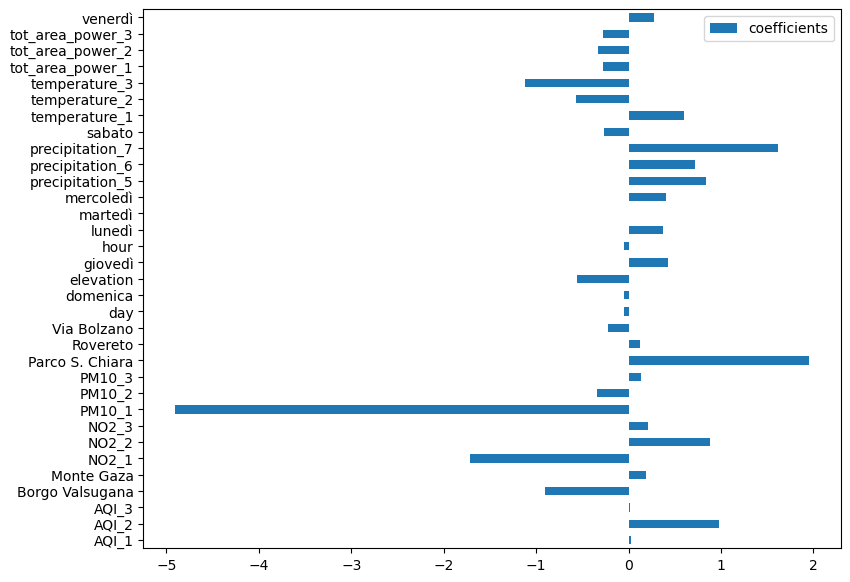

In [ ]:
# diamo un'occhiata ai pesi per ciascuna feature in modo da capire quali siano le feature importanti e quali invece quelle inutili
coefs_df = pd.DataFrame(LR_cv.coef_.T,columns=['coefficients'],index=feature_cols)
coefs_df.plot.barh(figsize=(9,7))

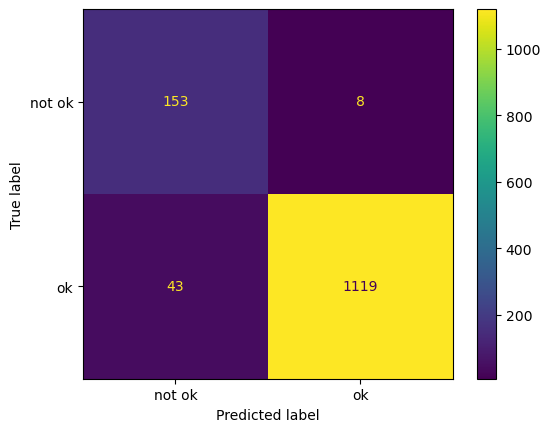

In [ ]:
# disegnamo la confusion matrix in modo da capire se il nostro modello funziona o no
y_pred = LR_cv.predict(scaled_X_test)
metrics.ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=LR_cv.classes_ # tira fuori i nomi delle classi
)

plt.show()

0.22923054682380614


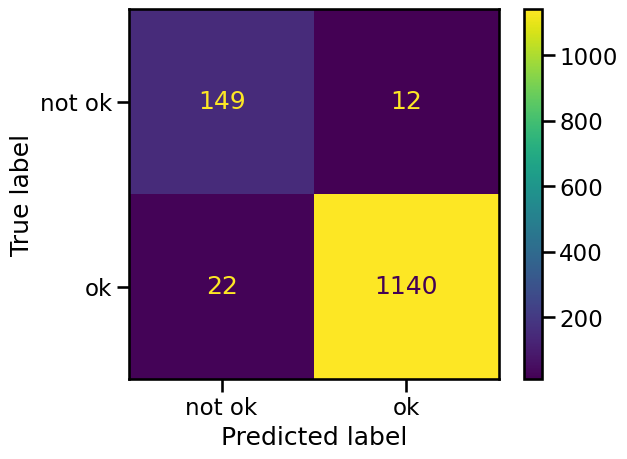

In [ ]:
# 1)
num_N = (y_test == 'not ok').sum()
num_P = (y_test == 'ok').sum()

y_proba = LR_cv.predict_proba(scaled_X_test)[:, 1] # restituisce le predizioni in forma di probabilità, quindi permette di disegnare la ROC
fpr,tpr,thr = metrics.roc_curve(y_test,y_proba,pos_label='ok')

mx = (num_N /num_P) * fpr
intercept = tpr[:-1] - mx[:-1]

best_idx = np.argmax(intercept)
best_thr = thr[best_idx]
print(best_thr)

y_pred = (y_proba >= best_thr).astype(int)
metrics.ConfusionMatrixDisplay.from_predictions(
    (y_test == 'ok').astype(int),
    y_pred,
    display_labels=['not ok', 'ok'] # tira fuori i nomi delle classi
)

plt.show()

0.1313145823033542


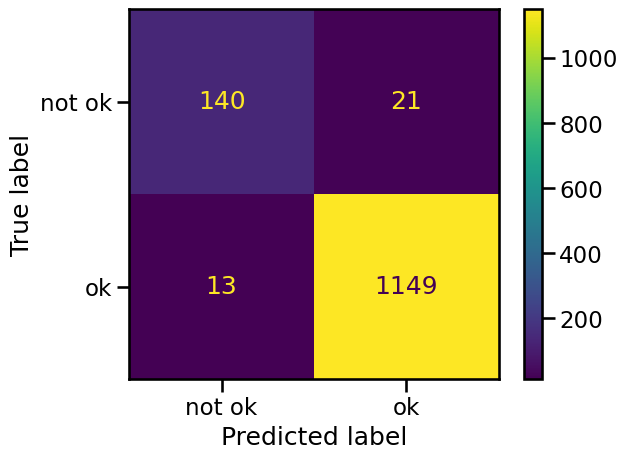

In [ ]:
# 2)
y_proba = LR_cv.predict_proba(scaled_X_test)[:, 1]
f1_score = []
for t in thr:
    y_pred = (y_proba >= t).astype(int)
    tn, fp, fn, tp = metrics.confusion_matrix((y_test == 'ok').astype(int), y_pred,).ravel()
    f1_score.append(2 * tp / (2 * tp + fp + fn))

best_idx = np.argmax(f1_score)
best_thr = thr[best_idx]
print(best_thr)

y_pred = (y_proba >= best_thr).astype(int)
metrics.ConfusionMatrixDisplay.from_predictions(
    (y_test == 'ok').astype(int),
    y_pred,
    display_labels=['not ok', 'ok'] # tira fuori i nomi delle classi
)

plt.show()

0.22923054682380614


/var/folders/kk/q9vd_8nn5w5cp7fcpz9zs4sh0000gn/T/ipykernel_12621/1914224085.py:10: RuntimeWarning: invalid value encountered in scalar divide
  MCC_score.append((tp * tn - fp * fn) / np.sqrt(pp * pn * ap * an))
/var/folders/kk/q9vd_8nn5w5cp7fcpz9zs4sh0000gn/T/ipykernel_12621/1914224085.py:10: RuntimeWarning: invalid value encountered in scalar divide
  MCC_score.append((tp * tn - fp * fn) / np.sqrt(pp * pn * ap * an))


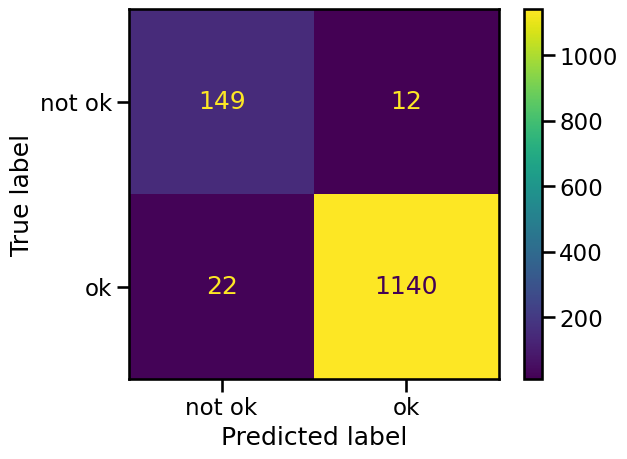

In [ ]:
y_proba = LR_cv.predict_proba(scaled_X_test)[:, 1]
MCC_score = []
for t in thr:
    y_pred = (y_proba >= t).astype(int)
    tn, fp, fn, tp = metrics.confusion_matrix((y_test == 'ok').astype(int), y_pred,).ravel()
    pp = tp + fp
    pn = tn + fn
    ap = tp + fn
    an = tn + fp
    MCC_score.append((tp * tn - fp * fn) / np.sqrt(pp * pn * ap * an))

best_idx = np.nanargmax(MCC_score)
best_thr = thr[best_idx]
print(best_thr)

y_pred = (y_proba >= best_thr).astype(int)
metrics.ConfusionMatrixDisplay.from_predictions(
    (y_test == 'ok').astype(int),
    y_pred,
    display_labels=['not ok', 'ok'] # tira fuori i nomi delle classi
)

plt.show()